# EDA - Suppliers Table

I'm going to go through this a little differently without the previous columns in the inventory table. I already done EDA on those columns before, and it seems pretty redundant to do another EDA on them again.

## Setup

In [1]:
import sys
sys.path.append('../')

import polars as pl

import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, URL
from utils.db_connection import connection_info

In [2]:
url = URL.create(
    drivername=connection_info['drivername'],
    username=connection_info['username'],
    password=connection_info['password'],
    host=connection_info['host'],
    port=connection_info['port'],
    database="retail"
)

engine = create_engine(url)

conn = engine.connect()

# SELECT * is a horrible idea in production, so I'm splitting up into 3 separate queries based on what type of data they have contained 
# Categorical data, numeric data, and datetime data
categorical_only = pl.read_database(
    query="""
        SELECT 
            order_id,
            invoice_matched_flag
        FROM supplier_orders
    """,
    connection=conn
)

numeric_only = pl.read_database(
    query="""
        SELECT 
            qty_ordered,
            qty_received,
            unit_cost_usd,
            total_order_value_usd,
            fill_rate_pct
        FROM supplier_orders
    """,
    connection=conn
)

datetime_only = pl.read_database(
    query="""
        SELECT 
            order_date,
            expected_delivery_date,
            actual_delivery_date
        FROM supplier_orders
    """,
    connection=conn
)

conn.close()

## Verification

In [3]:
categorical_only.head(10)

order_id,invoice_matched_flag
str,str
"""PO-50000""","""N"""
"""PO-50001""","""Y"""
"""PO-50002""","""0"""
"""PO-50003""","""Yes"""
"""PO-50004""","""n"""
"""PO-50005""","""1"""
"""PO-50006""","""0"""
"""PO-50007""","""y"""
"""PO-50008""","""N"""


In [4]:
categorical_only.null_count()

order_id,invoice_matched_flag
u32,u32
0,0


Invoice flag looks messy. Worth investigating.

In [5]:
numeric_only.head(10)

qty_ordered,qty_received,unit_cost_usd,total_order_value_usd,fill_rate_pct
i64,str,"decimal[38,2]","decimal[38,2]","decimal[38,2]"
157,"""115""",2.29,359.53,73.02
50,"""47""",3.19,159.50,94.68
102,"""64""",4.27,435.54,62.99
50,"""49""",5.46,273.00,98.32
81,"""71""",11.44,926.64,87.39
161,"""69""",5.01,806.61,43.04
95,"""89""",3.47,329.65,94.04
50,"""50""",9.23,461.50,99.03
50,"""50""",3.44,172.00,99.01


In [6]:
numeric_only.null_count()

qty_ordered,qty_received,unit_cost_usd,total_order_value_usd,fill_rate_pct
u32,u32,u32,u32,u32
0,0,0,0,0


Quantity received shouldn't be a string... odd. Also worth investigating.

In [7]:
datetime_only.head(10)

order_date,expected_delivery_date,actual_delivery_date
str,str,str
"""2021-09-07 22:55:10""","""2021-09-16""","""2021-09-20 18:46:59"""
"""2022-02-20 07:10:15""","""2022-02-28""","""2022-03-02 01:35:05"""
"""2024-06-18 08:14:55""","""2024-06-27""","""2024-06-27 14:10:19"""
"""2022-08-31 17:50:16""","""2022-09-14""","""2022-09-14 09:08:28"""
"""2021-04-17 16:49:35""","""2021-04-25""","""2021-04-25 09:30:02"""
"""2021-11-02 16:24:39""","""2021-11-15""","""2021-11-18 00:16:06"""
"""2021-12-02 09:19:49""","""2021-12-08""","""2021-12-06 12:52:39"""
"""2022-08-03 01:49:53""","""2022-08-17""","""2022-08-16 10:02:24"""
"""TBD""","""2024-07-12""","""2024-07-10 20:57:07"""


In [8]:
datetime_only.null_count()

order_date,expected_delivery_date,actual_delivery_date
u32,u32,u32
0,0,2892


Plenty of nulls in the actual delivery date column. Seems like there are some ghost orders + maybe some orders that haven't been delivered yet? Need to investigate this.
Also, I spotted a "TBD" in the order_date column as well. Interesting.

## Categorical

Let's check the order_ids to see if there's any duplicates.

In [9]:
categorical_only.select(pl.col('order_id')).is_duplicated().value_counts()

,count
bool,u32
false,80000


Doesn't look like there's any duplicates!

Now let's deal with the messy flag column.

In [10]:
categorical_only.select(
    pl.col('invoice_matched_flag').unique()
)

invoice_matched_flag
str
"""Y"""
"""TRUE"""
"""FALSE"""
"""No"""
"""n"""
"""y"""
"""0"""
"""Yes"""
"""1"""


Similar story to the markdown flag in the inventory table.

## Numerical

First things first - what's going on with the quantity received column?

In [11]:
numeric_only.select(
    pl.col('qty_received').value_counts()
).unnest('qty_received').sort(by='count', descending=True)

qty_received,count
str,u32
"""47""",2082
"""46""",2044
"""48""",1998
"""44""",1823
"""45""",1813
…,…
"""822""",1
"""274 units""",1
"""329 units""",1


Huh... on one hand we have a "pending" string that presumably indicates that the order hasn't arrived yet. On the other hand, there's some values that say something like "19 units" that need to be cleaned up.

I want this as an integer, which means I have to:
1. Clean up all the strings that have "x units"
2. Convert any non-numeric strings into nulls

Let's join with the datetime dataframe to see if my intuition is correct.

In [12]:
numeric_only.select(
    pl.col('qty_received')
).with_columns(
    datetime_only.select('*')
).filter(pl.col('qty_received') == 'pending')

qty_received,order_date,expected_delivery_date,actual_delivery_date
str,str,str,str
"""pending""","""2024-12-23 13:36:41""","""2024-12-28""",null
"""pending""","""2024-12-21 23:59:23""","""2024-12-31""",null
"""pending""","""2024-12-10 16:06:29""","""2024-12-24""",null
"""pending""","""2024-12-05 04:02:00""","""2024-12-11""",null
"""pending""","""2024-12-30 15:38:51""","""2025-01-04""",null
…,…,…,…
"""pending""","""2024-12-14 10:10:46""","""2024-12-22""",null
"""pending""","""2024-12-12 18:56:47""","""2024-12-13""",null
"""pending""","""2024-02-17 23:16:08""","""2024-02-28""",null


Most orders weren't delivered yet, while others... are ghost orders.

Summary stats! First, let's clean up the quantity received column.

In [13]:
numeric_only = numeric_only.with_columns(
    pl.col('qty_received').str.replace(pattern=" units", value="").str.to_integer(strict=False)
)

In [14]:
numeric_only.describe()

statistic,qty_ordered,qty_received,unit_cost_usd,total_order_value_usd,fill_rate_pct
str,f64,f64,f64,f64,f64
"""count""",80000.0,79847.0,80000.0,80000.0,80000.0
"""null_count""",0.0,153.0,0.0,0.0,0.0
"""mean""",127.808863,105.878981,7.16741,909.035885,82.825506
"""std""",111.30941,95.619434,6.50702,1334.536346,14.79603
"""min""",50.0,0.0,0.44,22.0,0.03
"""25%""",52.0,47.0,2.38,222.5,77.25
"""50%""",90.0,73.0,5.01,474.0,86.31
"""75%""",155.0,129.0,9.41,1049.5,92.83
"""max""",1000.0,998.0,30.0,28740.0,99.99


Plenty of right skew (and a little bit of left skew as well).

<Axes: xlabel='qty_ordered', ylabel='Count'>

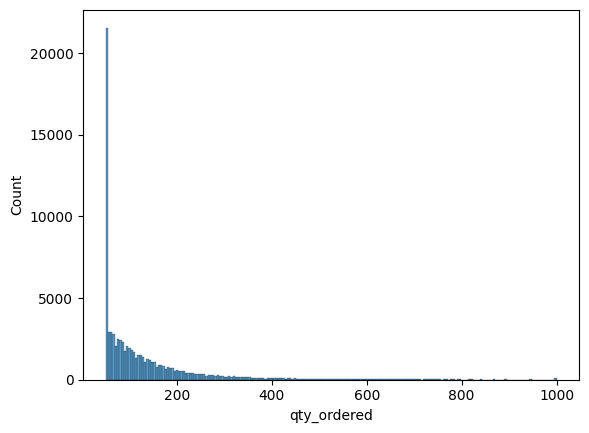

In [15]:
df = numeric_only.to_pandas()
sns.histplot(data=df, x='qty_ordered')

<Axes: xlabel='qty_ordered'>

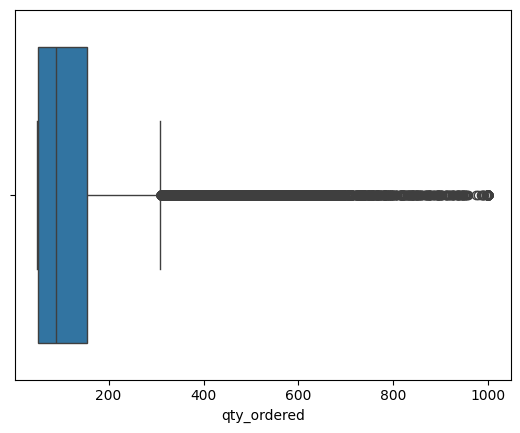

In [16]:
sns.boxplot(data=df, x='qty_ordered')

<Axes: xlabel='qty_received', ylabel='Count'>

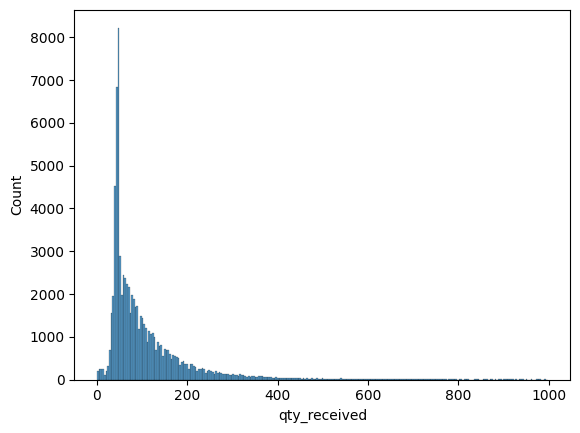

In [17]:
sns.histplot(data=df, x='qty_received')

<Axes: xlabel='qty_received'>

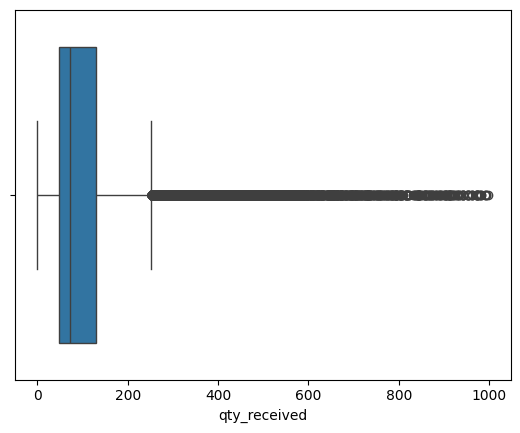

In [18]:
sns.boxplot(data=df, x='qty_received')

<Axes: xlabel='unit_cost_usd', ylabel='Count'>

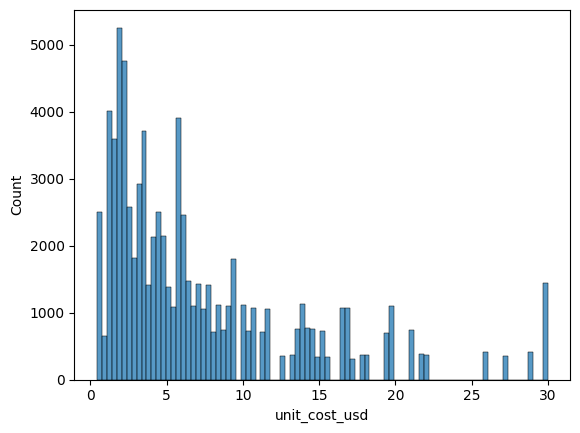

In [19]:
sns.histplot(data=df, x='unit_cost_usd')

<Axes: xlabel='unit_cost_usd'>

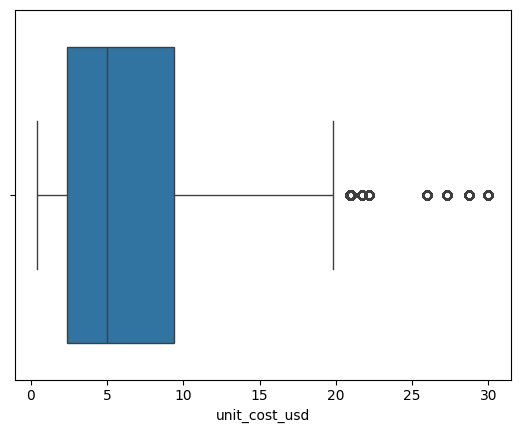

In [20]:
sns.boxplot(data=df, x='unit_cost_usd')

<Axes: xlabel='total_order_value_usd', ylabel='Count'>

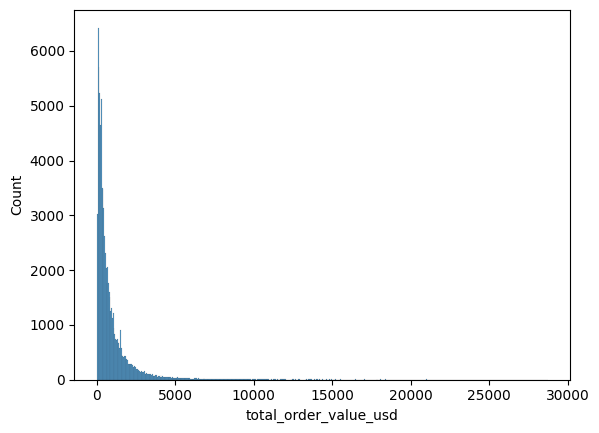

In [21]:
sns.histplot(data=df, x='total_order_value_usd')

<Axes: xlabel='total_order_value_usd'>

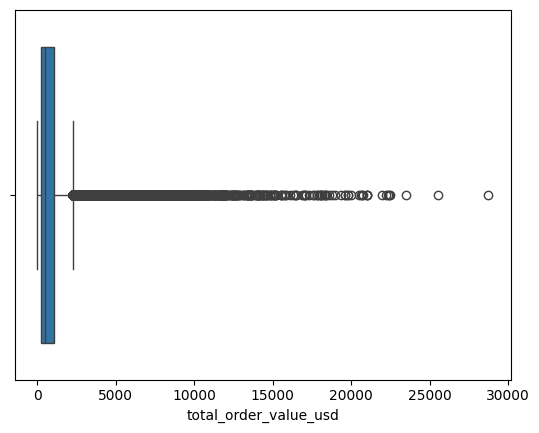

In [22]:
sns.boxplot(data=df, x='total_order_value_usd')

<Axes: xlabel='fill_rate_pct', ylabel='Count'>

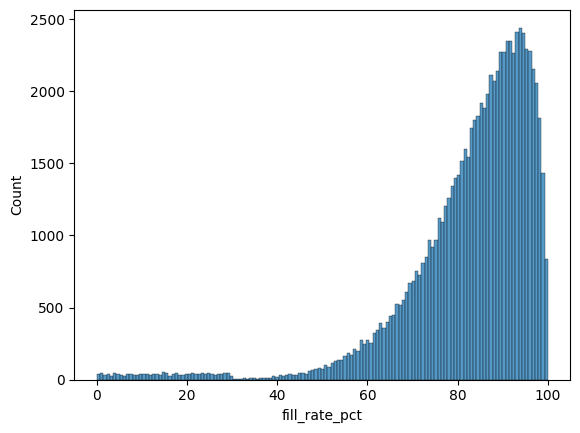

In [23]:
sns.histplot(data=df, x='fill_rate_pct')

<Axes: xlabel='fill_rate_pct'>

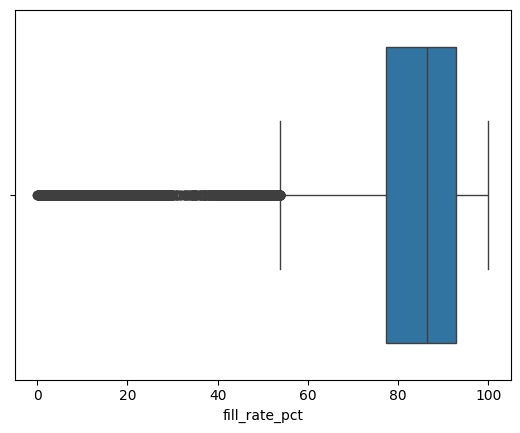

In [ ]:
sns.boxplot(data=df, x='fill_rate_pct')

## Datetimes

Let's observe the messy order_date column first.

In [ ]:
datetime_only.select(
    pl.col('order_date').value_counts()
).unnest('order_date').sort(by='count', descending=True)

order_date,count
str,u32
"""??""",1038
"""N/A""",1013
"""TBD""",1008
"""""",997
"""2022-04-01 21:02:50""",2
…,…
"""2024-09-21 05:17:08""",1
"""2021-06-04 09:50:14""",1
"""2024-02-11 05:56:56""",1


Hmmm... plenty of messy values there. Might just convert them to nulls since I can't really fake the data. 

In [35]:
datetime_only.select(
    pl.col("expected_delivery_date").str.to_date()
)

expected_delivery_date
date
2021-09-16
2022-02-28
2024-06-27
2022-09-14
2021-04-25
…
2023-06-04
2023-03-14
2021-01-11


Looks good.

Now, what about the actual delivery date column? Is there a pattern?

In [44]:
datetime_only.select(
    pl.col("expected_delivery_date"),
    pl.col("actual_delivery_date")
).filter(pl.col("actual_delivery_date").is_null()).unique().sort(by='expected_delivery_date', descending=False)

expected_delivery_date,actual_delivery_date
str,str
"""2021-01-11""",null
"""2021-01-14""",null
"""2021-01-22""",null
"""2021-01-25""",null
"""2021-01-26""",null
…,…
"""2025-01-09""",null
"""2025-01-10""",null
"""2025-01-11""",null


Yep. Seems like some orders are ghost orders, while others may be recently placed orders that haven't been delivered yet (the dataset ranges from 2021 to 2025.)